# 02a — Path A: Subject-Level Cross-Subject Classifier

Target: `Rest_tremor` (binary)
Validation: Leave-One-Subject-Out (LOSO) Cross-Validation

In [1]:
# ── PATH A: Subject-Level Classification ──────────────────────────────
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, classification_report

df = pd.read_csv('../data/ALAMEDA_PD_tremor_dataset.csv')

META   = ['start_timestamp', 'end_timestamp', 'subject_id']
LABELS = ['Rest_tremor', 'Postural_tremor', 'Kinetic_tremor', 'Constancy_of_rest']
FEATURE_COLS = [c for c in df.columns if c not in META + LABELS]

# any_tremor: 1 if ANY tremor label is positive
df['any_tremor'] = ((df['Rest_tremor'] == 1) |
                    (df['Postural_tremor'] == 1) |
                    (df['Kinetic_tremor'] == 1)).astype(int)

X      = df[FEATURE_COLS].values
y      = df['any_tremor'].values
groups = df['subject_id'].values
subjects = np.unique(groups)

# ── Aggregate per subject (mean + std across windows) ──────────────────
subject_rows = []
for s in subjects:
    mask = groups == s
    feat_mean = X[mask].mean(axis=0)
    feat_std  = X[mask].std(axis=0)
    feat_vec  = np.concatenate([feat_mean, feat_std])   # 184 features
    label     = int(y[mask].max())                       # 1 if any window has tremor
    subject_rows.append({'subject': s, 'features': feat_vec, 'label': label})

X_subj = np.array([r['features'] for r in subject_rows])
y_subj = np.array([r['label']    for r in subject_rows])

print("Subject-level dataset:")
for r in subject_rows:
    print(f"  Subject {r['subject']:2d} | label={r['label']}")
print(f"\nClass balance — 0: {(y_subj==0).sum()}, 1: {(y_subj==1).sum()}")

# ── LOSO on 11 subjects ────────────────────────────────────────────────
results = []
for i, s in enumerate(subjects):
    train_idx = np.arange(len(subjects)) != i

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_subj[train_idx])
    X_test  = scaler.transform(X_subj[[i]])
    y_train = y_subj[train_idx]
    y_true  = y_subj[i]

    # L2 Logistic — better than RF for N=10 training points
    clf = LogisticRegression(C=0.1, class_weight='balanced',
                              solver='lbfgs', max_iter=1000)
    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)[0]
    prob = clf.predict_proba(X_test)[0][1]

    results.append({'subject': s, 'true': y_true, 'pred': pred, 'prob': prob})
    status = "✓" if pred == y_true else "✗"
    print(f"Subject {s:2d} | True: {y_true} | Pred: {pred} | Prob: {prob:.3f} {status}")

results_df = pd.DataFrame(results)
acc = (results_df['true'] == results_df['pred']).mean()
print(f"\nSubject-level LOO Accuracy: {acc:.3f}  ({int(acc*len(subjects))}/{len(subjects)} correct)")
print("Note: N=11 — report as jackknife LOO, not robust LOSO")

Subject-level dataset:
  Subject  2 | label=0
  Subject  4 | label=1
  Subject  7 | label=1
  Subject  8 | label=0
  Subject  9 | label=1
  Subject 11 | label=0
  Subject 12 | label=0
  Subject 13 | label=0
  Subject 14 | label=1
  Subject 15 | label=1
  Subject 16 | label=1

Class balance — 0: 5, 1: 6
Subject  2 | True: 0 | Pred: 0 | Prob: 0.436 ✓
Subject  4 | True: 1 | Pred: 1 | Prob: 0.591 ✓
Subject  7 | True: 1 | Pred: 0 | Prob: 0.392 ✗
Subject  8 | True: 0 | Pred: 1 | Prob: 0.519 ✗
Subject  9 | True: 1 | Pred: 0 | Prob: 0.336 ✗
Subject 11 | True: 0 | Pred: 0 | Prob: 0.472 ✓
Subject 12 | True: 0 | Pred: 0 | Prob: 0.046 ✓
Subject 13 | True: 0 | Pred: 0 | Prob: 0.273 ✓
Subject 14 | True: 1 | Pred: 1 | Prob: 0.914 ✓
Subject 15 | True: 1 | Pred: 1 | Prob: 0.975 ✓
Subject 16 | True: 1 | Pred: 1 | Prob: 0.740 ✓

Subject-level LOO Accuracy: 0.727  (8/11 correct)
Note: N=11 — report as jackknife LOO, not robust LOSO


# Path B: Within-Subject Personalized Detector


In [2]:
# ── PATH B: Within-Subject (Stratified Split) ─────────────────────────
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, classification_report
import numpy as np

WITHIN_SUBJECTS = [4, 14]

for s in WITHIN_SUBJECTS:
    mask   = groups == s
    X_s    = X[mask]
    y_s    = y[mask]

    print(f"\n── Subject {s} ──────────────────────")
    print(f"  Total windows: {len(y_s)} | pos={y_s.sum()}, neg={(y_s==0).sum()}")

    if len(np.unique(y_s)) < 2:
        print("  ⚠ Only one class present — skipping")
        continue

    # Stratified split preserves the pos/neg ratio in both train and test
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(sss.split(X_s, y_s))

    X_train, X_test = X_s[train_idx], X_s[test_idx]
    y_train, y_test = y_s[train_idx], y_s[test_idx]

    print(f"  Train: {len(y_train)} | pos={y_train.sum()}, neg={(y_train==0).sum()}")
    print(f"  Test:  {len(y_test)}  | pos={y_test.sum()}, neg={(y_test==0).sum()}")

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
    clf.fit(X_tr_sc, y_train)

    y_pred = clf.predict(X_te_sc)
    y_prob = clf.predict_proba(X_te_sc)[:, 1]

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_prob)
    print(f"\n  Balanced Accuracy: {bal_acc:.3f}")
    print(f"  ROC-AUC:           {auc:.3f}")
    print(classification_report(y_test, y_pred, target_names=['No Tremor', 'Tremor']))


── Subject 4 ──────────────────────
  Total windows: 1050 | pos=525, neg=525
  Train: 735 | pos=368, neg=367
  Test:  315  | pos=157, neg=158

  Balanced Accuracy: 0.718
  ROC-AUC:           0.788
              precision    recall  f1-score   support

   No Tremor       0.73      0.68      0.71       158
      Tremor       0.70      0.75      0.73       157

    accuracy                           0.72       315
   macro avg       0.72      0.72      0.72       315
weighted avg       0.72      0.72      0.72       315


── Subject 14 ──────────────────────
  Total windows: 350 | pos=175, neg=175
  Train: 245 | pos=123, neg=122
  Test:  105  | pos=52, neg=53

  Balanced Accuracy: 0.819
  ROC-AUC:           0.859
              precision    recall  f1-score   support

   No Tremor       0.85      0.77      0.81        53
      Tremor       0.79      0.87      0.83        52

    accuracy                           0.82       105
   macro avg       0.82      0.82      0.82       105
weighte

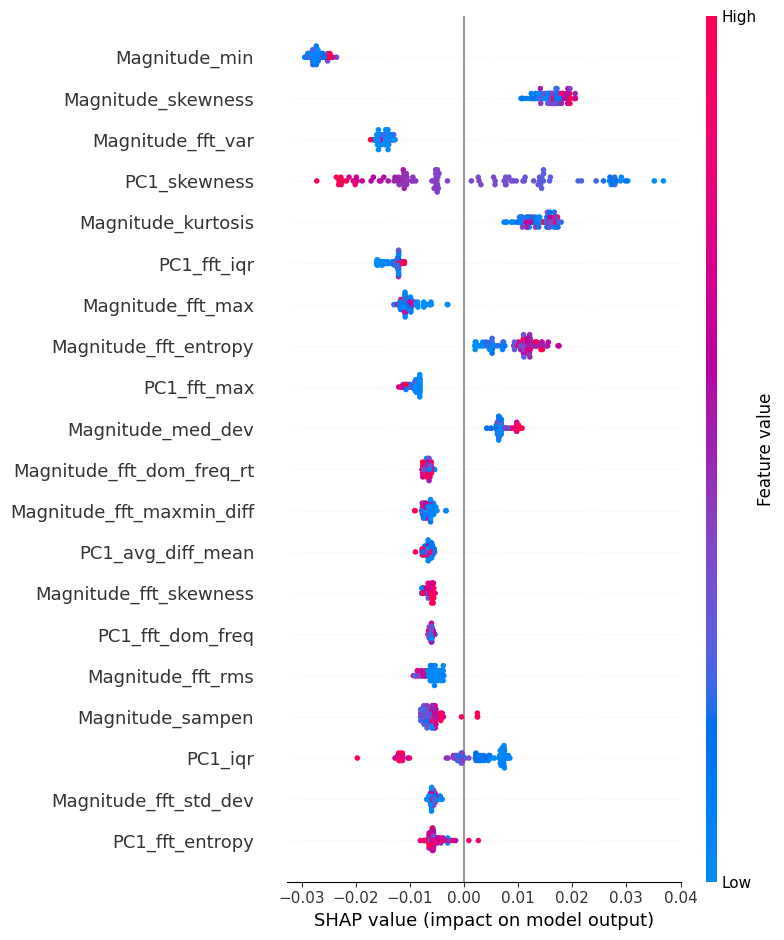

In [3]:
# Three things worth adding now:

# 1. Probability calibration — RF probabilities are often overconfident
from sklearn.calibration import CalibratedClassifierCV
clf_cal = CalibratedClassifierCV(clf, method='isotonic', cv=5)

# 2. Threshold tuning — default 0.5 is rarely optimal
# Plot precision-recall curve and pick threshold at max F1 or target recall ≥ 0.85
from sklearn.metrics import precision_recall_curve
prec, rec, thresholds = precision_recall_curve(y_test, y_prob)

# 3. SHAP for explainability (beats feature importance for a demo/poster)
import shap
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[1], X_test, feature_names=FEATURE_COLS)